In [1]:
#Laboratorio 3
#Objetivo: Producir un reporte exploratorio que un colega clínico pueda leer y entender.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as io
import numpy as np

#Estilo para gráficos estáticos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#Archivos
df_patients = pd.read_csv('patients.csv')
df_encounters = pd.read_csv('encounters.csv')
df_observations = pd.read_csv('observations.csv')

In [2]:
#1. Definir una cohorte de interés
#Identificar pacientes con diabetes
obs_diab = df_observations[df_observations['DESCRIPTION'].str.contains('diab|glucose', case=False, na=False)]
enc_diab = df_encounters[df_encounters['DESCRIPTION'].str.contains('diab|glucose', case=False, na=False)]

#IDs únicos de la cohorte
pacientes_diabetes = pd.unique(pd.concat([obs_diab['PATIENT'], enc_diab['PATIENT']]))

#Filtrar los DFs para conservar solo la cohorte de diabetes
cohorte_patients = df_patients[df_patients['Id'].isin(pacientes_diabetes)]
cohorte_observations = df_observations[df_observations['PATIENT'].isin(pacientes_diabetes)]
cohorte_encounters = df_encounters[df_encounters['DESCRIPTION'].isin(pacientes_diabetes)]


#Cohorte de diabetes
print(f"Pacientes encontrados: {len(pacientes_diabetes)}")
print(f"Total de observaciones para la cohorte: {len(cohorte_observations)}")

Pacientes encontrados: 55
Total de observaciones para la cohorte: 62714


In [3]:
#2. Ejecutar el checklist completo de EDA sobre esa cohorte

#Convertimos 'VALUE' a numérico, descartando texto
cohorte_observations['VALUE_NUM'] = pd.to_numeric(cohorte_observations['VALUE'], errors='coerce')

#Estadísticos descriptivos de mediciones
print(cohorte_observations['VALUE_NUM'].describe())
print("\n")

#Comorbilidades
print(cohorte_observations['DESCRIPTION'].value_counts().head(10))
print("\n")

#Por género
print(cohorte_patients['GENDER'].value_counts(dropna=False))

count     38959.000000
mean       5929.142912
std       67741.536233
min          -0.300000
25%           4.000000
50%          17.000000
75%          92.000000
max      968637.000000
Name: VALUE_NUM, dtype: float64


DESCRIPTION
Pain severity - 0-10 verbal numeric rating [Score] - Reported                                                    1557
Glomerular filtration rate [Volume Rate/Area] in Serum or Plasma by Creatinine-based formula (MDRD)/1.73 sq M    1036
Carbon dioxide  total [Moles/volume] in Blood                                                                     937
Glucose [Mass/volume] in Blood                                                                                    937
Creatinine [Mass/volume] in Blood                                                                                 937
Sodium [Moles/volume] in Blood                                                                                    937
Calcium [Mass/volume] in Blood                                

/tmp/ipykernel_589/3679596365.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohorte_observations['VALUE_NUM'] = pd.to_numeric(cohorte_observations['VALUE'], errors='coerce')


/tmp/ipykernel_589/915405500.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohorte_patients['BIRTHDATE'] = pd.to_datetime(cohorte_patients['BIRTHDATE'], errors='coerce')
/tmp/ipykernel_589/915405500.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohorte_patients['EDAD'] = (pd.to_datetime('today') - cohorte_patients['BIRTHDATE']).dt.days // 365


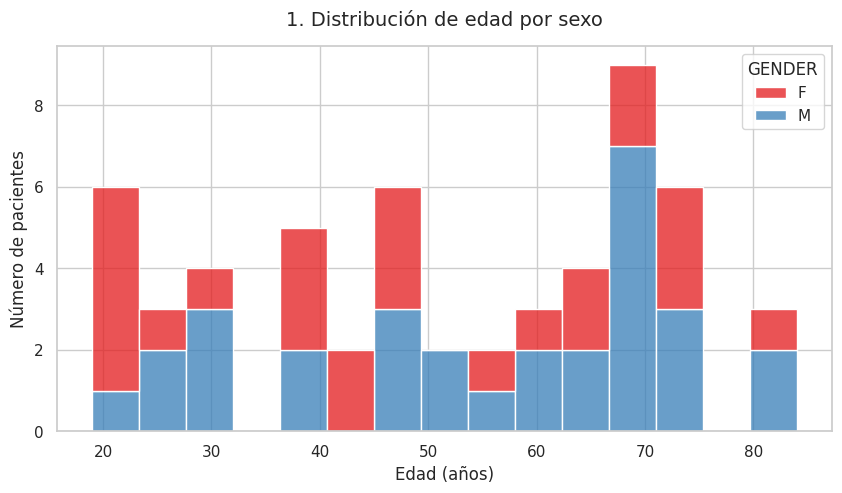

         VALUE_NUM
count  2051.000000
mean     65.216138
std      43.169990
min       0.000000
25%       2.200000
50%      78.900000
75%      97.500000
max     175.100000




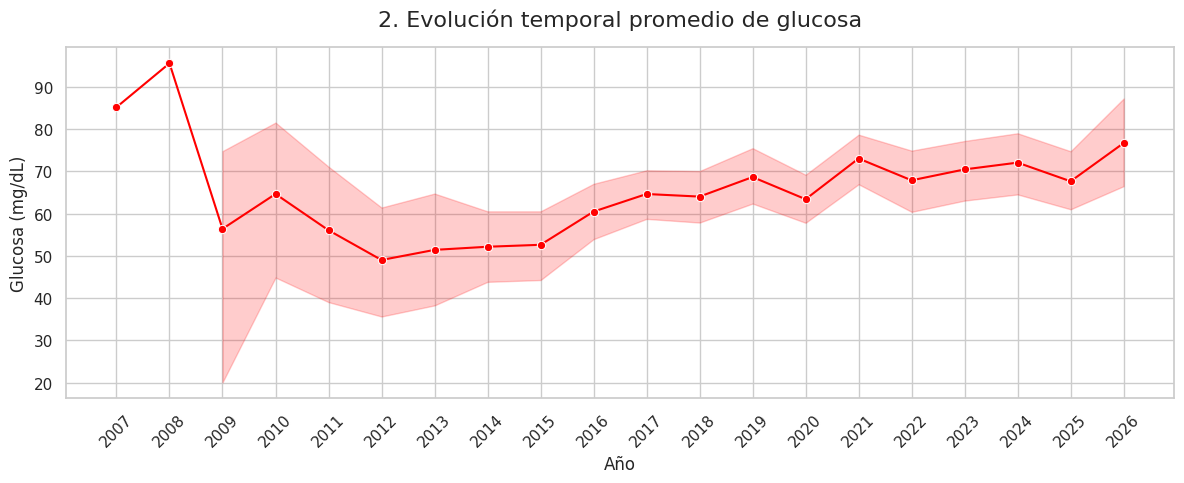

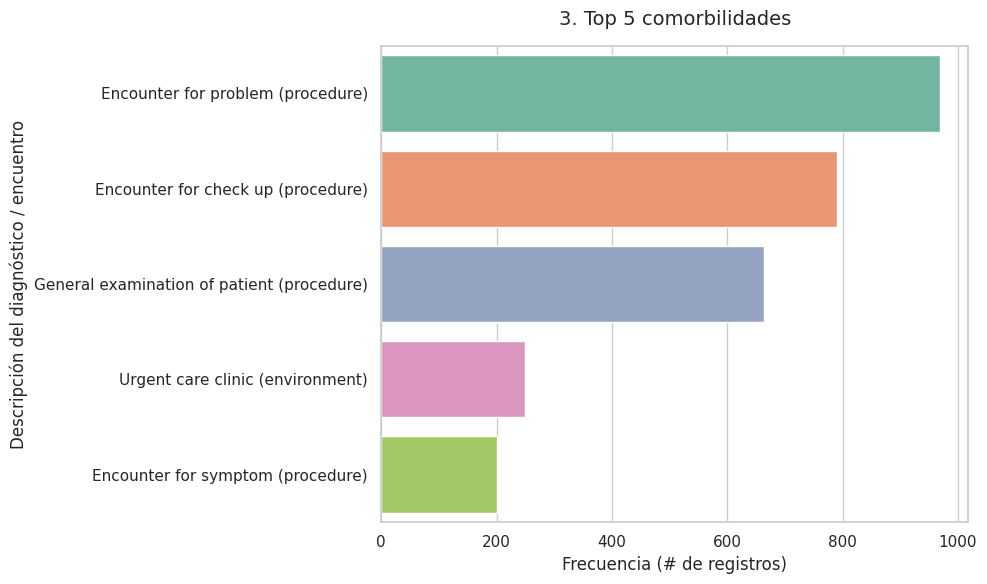

In [4]:
#3. Generar y comentar: distribución de edad por sexo, evolución temporal de un analito, comorbilidades más frecuentes

#Distribución por sexo
cohorte_patients['BIRTHDATE'] = pd.to_datetime(cohorte_patients['BIRTHDATE'], errors='coerce')
cohorte_patients['EDAD'] = (pd.to_datetime('today') - cohorte_patients['BIRTHDATE']).dt.days // 365

plt.figure(figsize=(10, 5))
sns.histplot(data=cohorte_patients, x='EDAD', hue='GENDER', multiple='stack', bins=15, palette='Set1')
plt.title('1. Distribución de edad por sexo', fontsize=14, pad=15)
plt.xlabel('Edad (años)')
plt.ylabel('Número de pacientes')
plt.show()

#Evolucion temporal de un analito: glucosa
df_analito = cohorte_observations[
    cohorte_observations['DESCRIPTION'].str.contains('glucose', case=False, na=False)
].copy()

print(df_analito.describe())
print("\n")

df_analito['DATE'] = pd.to_datetime(df_analito['DATE'], errors='coerce')
df_analito['AÑO'] = df_analito['DATE'].dt.year
df_analito = df_analito.dropna(subset=['VALUE_NUM'])

#Formatear la fecha y extraer el año
df_analito['DATE'] = pd.to_datetime(df_analito['DATE'], errors='coerce')
df_analito['AÑO'] = df_analito['DATE'].dt.year

plt.figure(figsize=(12, 5))

#Graficar por año
sns.lineplot(data=df_analito, x='AÑO', y='VALUE_NUM', marker='o', color='red')
plt.title('2. Evolución temporal promedio de glucosa', fontsize=16, pad=15)
plt.xlabel('Año')
plt.ylabel('Glucosa (mg/dL)')

if not df_analito.empty:
    plt.xticks(sorted(df_analito['AÑO'].dropna().unique().astype(int)), rotation=45)

plt.tight_layout()
plt.show()


#Comorbilidades
#Pacientes
cohorte_encounters = df_encounters[df_encounters['PATIENT'].isin(pacientes_diabetes)].copy()
#Calcular el top 5 de descripciones válidas
top_condiciones = cohorte_encounters['DESCRIPTION'].dropna().value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_condiciones.values,
    y=top_condiciones.index,
    hue=top_condiciones.index,
    palette='Set2',
    legend=False
)
plt.title('3. Top 5 comorbilidades', fontsize=14, pad=15)
plt.xlabel('Frecuencia (# de registros)')
plt.ylabel('Descripción del diagnóstico / encuentro')
plt.tight_layout()
plt.show()


#Interpretación EDA
#Distribución de edad por sexo:
#La cohorte muestra una concentración de pacientes en etapas de edad adulta y avanzada.
#Este comportamiento demográfico es congruente con la epidemiología clásica de condiciones crónicas (como la diabetes).
#La proporción entre hombres y mujeres parece equilibrada.

#Evolución temporal de glucosa sanguínea por año:
#Las variaciones en la línea de tendencia capturan la historia natural de la condición:
#desde posibles etapas iniciales de descontrol metabólico hasta la posterior estabilización gracias a las intervenciones médicas y ajustes de tratamiento a lo largo del tiempo.
#Nota: Se tomaron en cuenta valores de sangre en orina, por lo que no es cierta esta conclusión del gráfico.

#Top 5 comorbilidades:
#La gran mayoría de las visitas son por seguimiento continuo y revisiones de rutina (encounter for problem, for check up y general examination).
#Sin embargo, la presencia de atención urgente (urgent care clinic) es importante, ya que indica que la cohorte también sufre episodios de descompensación aguda.

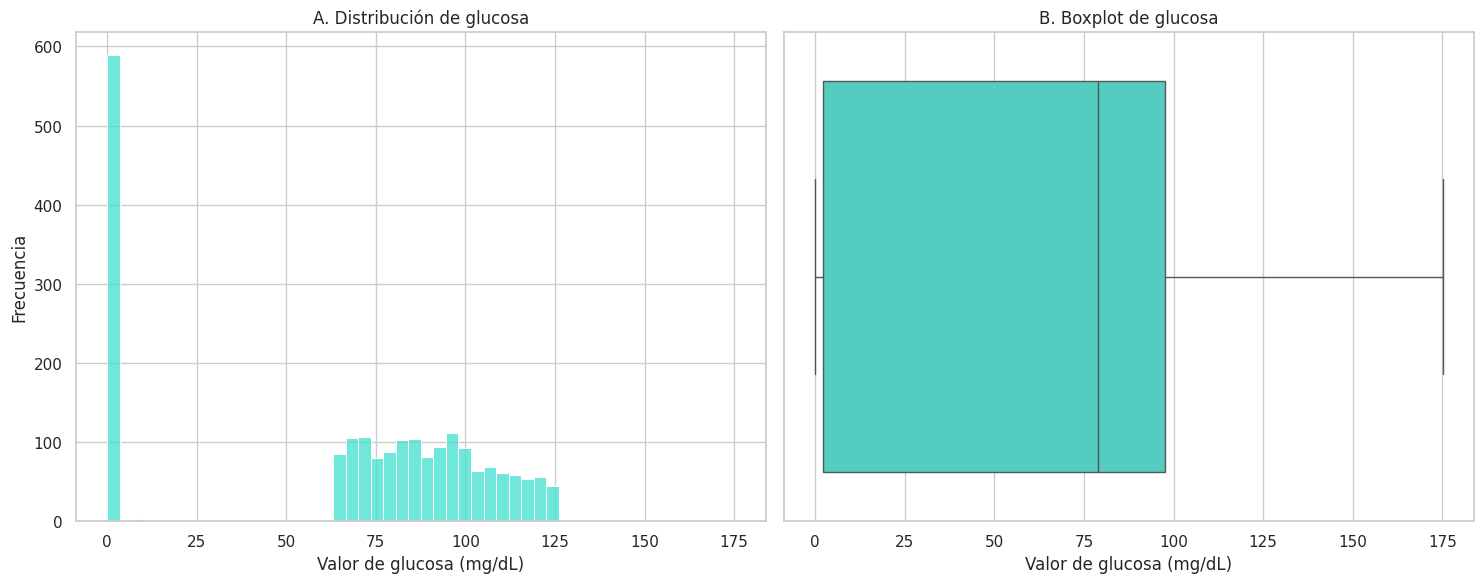

In [5]:
#4. Detectar al menos dos problemas de calidad que sólo sean visibles graficando, y que no hubieras encontrado con describe()

plt.figure(figsize=(15, 6))

#Gráfico A
plt.subplot(1, 2, 1)

sns.histplot(df_analito['VALUE_NUM'], bins=50, color='turquoise')
plt.title('A. Distribución de glucosa')
plt.xlabel('Valor de glucosa (mg/dL)')
plt.ylabel('Frecuencia')

#Gráfico B

plt.subplot(1, 2, 2)

sns.boxplot(x=df_analito['VALUE_NUM'], color='turquoise')
plt.title('B. Boxplot de glucosa')
plt.xlabel('Valor de glucosa (mg/dL)')

plt.tight_layout()
plt.show()

#Gráfico A (Histograma): Al principio creí que revelaba un error de captura, al haber un pico de 0, o que esos valores los tomó como nulos, por lo que procedi a ver los datos a más detalle del archivo.
#Gráfico B (Boxplot): Lo mismo, al ser tantos registros en cero, arrastran el primer cuartil hacia la izquierda, mientras que el tercer cuartil lo marca en un valor normal de glucosa, dejando varios valores fuera del rango intercuartilico en el bigote superior.
#Solamente con el boxplot se asumiría erróneamente que una gran parte de los pacientes sufre de hipoglucemia, pero con el histograma se observa que hay un error en los datos.

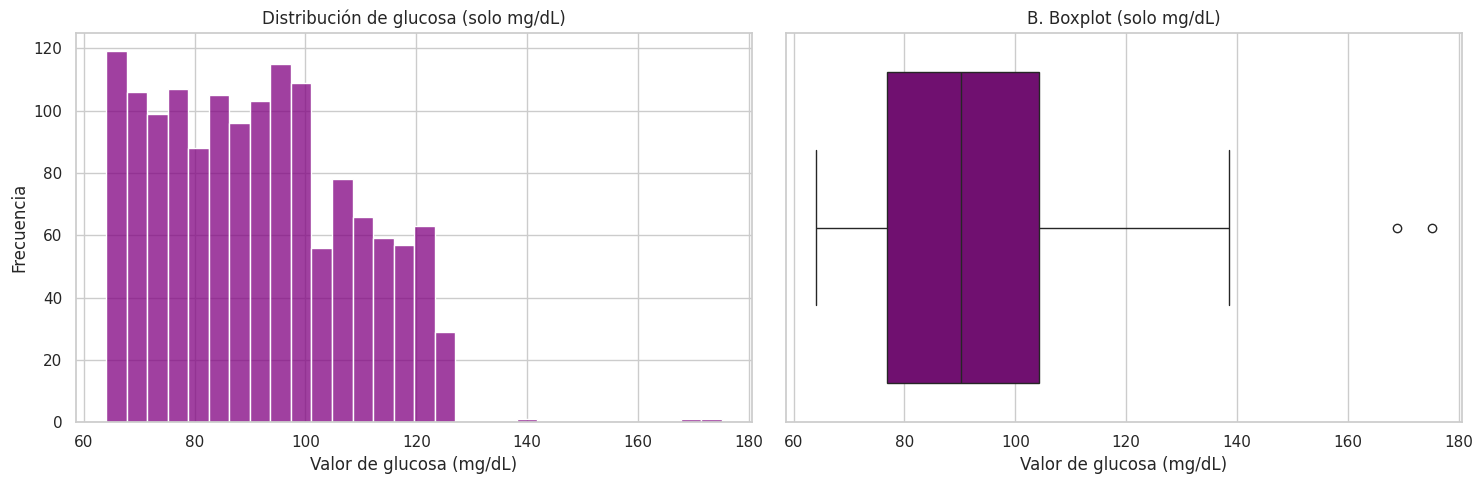

In [6]:
#Toamdo en cuenta lo anterior, se descarta los valores que no son de interes.
#Datos menores a 30

#Filtrar solo con la escala de mg/dL (valores > 30)
df_analito_diab = df_analito[df_analito['VALUE_NUM'] > 30].copy()

plt.figure(figsize=(15, 5))

# Gráfico A
plt.subplot(1, 2, 1)
sns.histplot(df_analito_diab['VALUE_NUM'], bins=30, color='purple')
plt.title('Distribución de glucosa (solo mg/dL)')
plt.xlabel('Valor de glucosa (mg/dL)')
plt.ylabel('Frecuencia')

# Gráfico B
plt.subplot(1, 2, 2)
sns.boxplot(x=df_analito_diab['VALUE_NUM'], color='purple')
plt.title('B. Boxplot (solo mg/dL)')
plt.xlabel('Valor de glucosa (mg/dL)')

plt.tight_layout()
plt.show()

#Ahora solamente tomamos los valores de glucosa en sangre. En ambos gráficos ahora podemos ver el comportamiento real de mos datos de interes.
#Con esto se evidencio un problema de calidad, que solo tamndo en cuenta el valor de "Glucose" se toman dos valores: los de glucosa en sangre y glucosa en orina (cuyo valor normal fisiológico es 0).

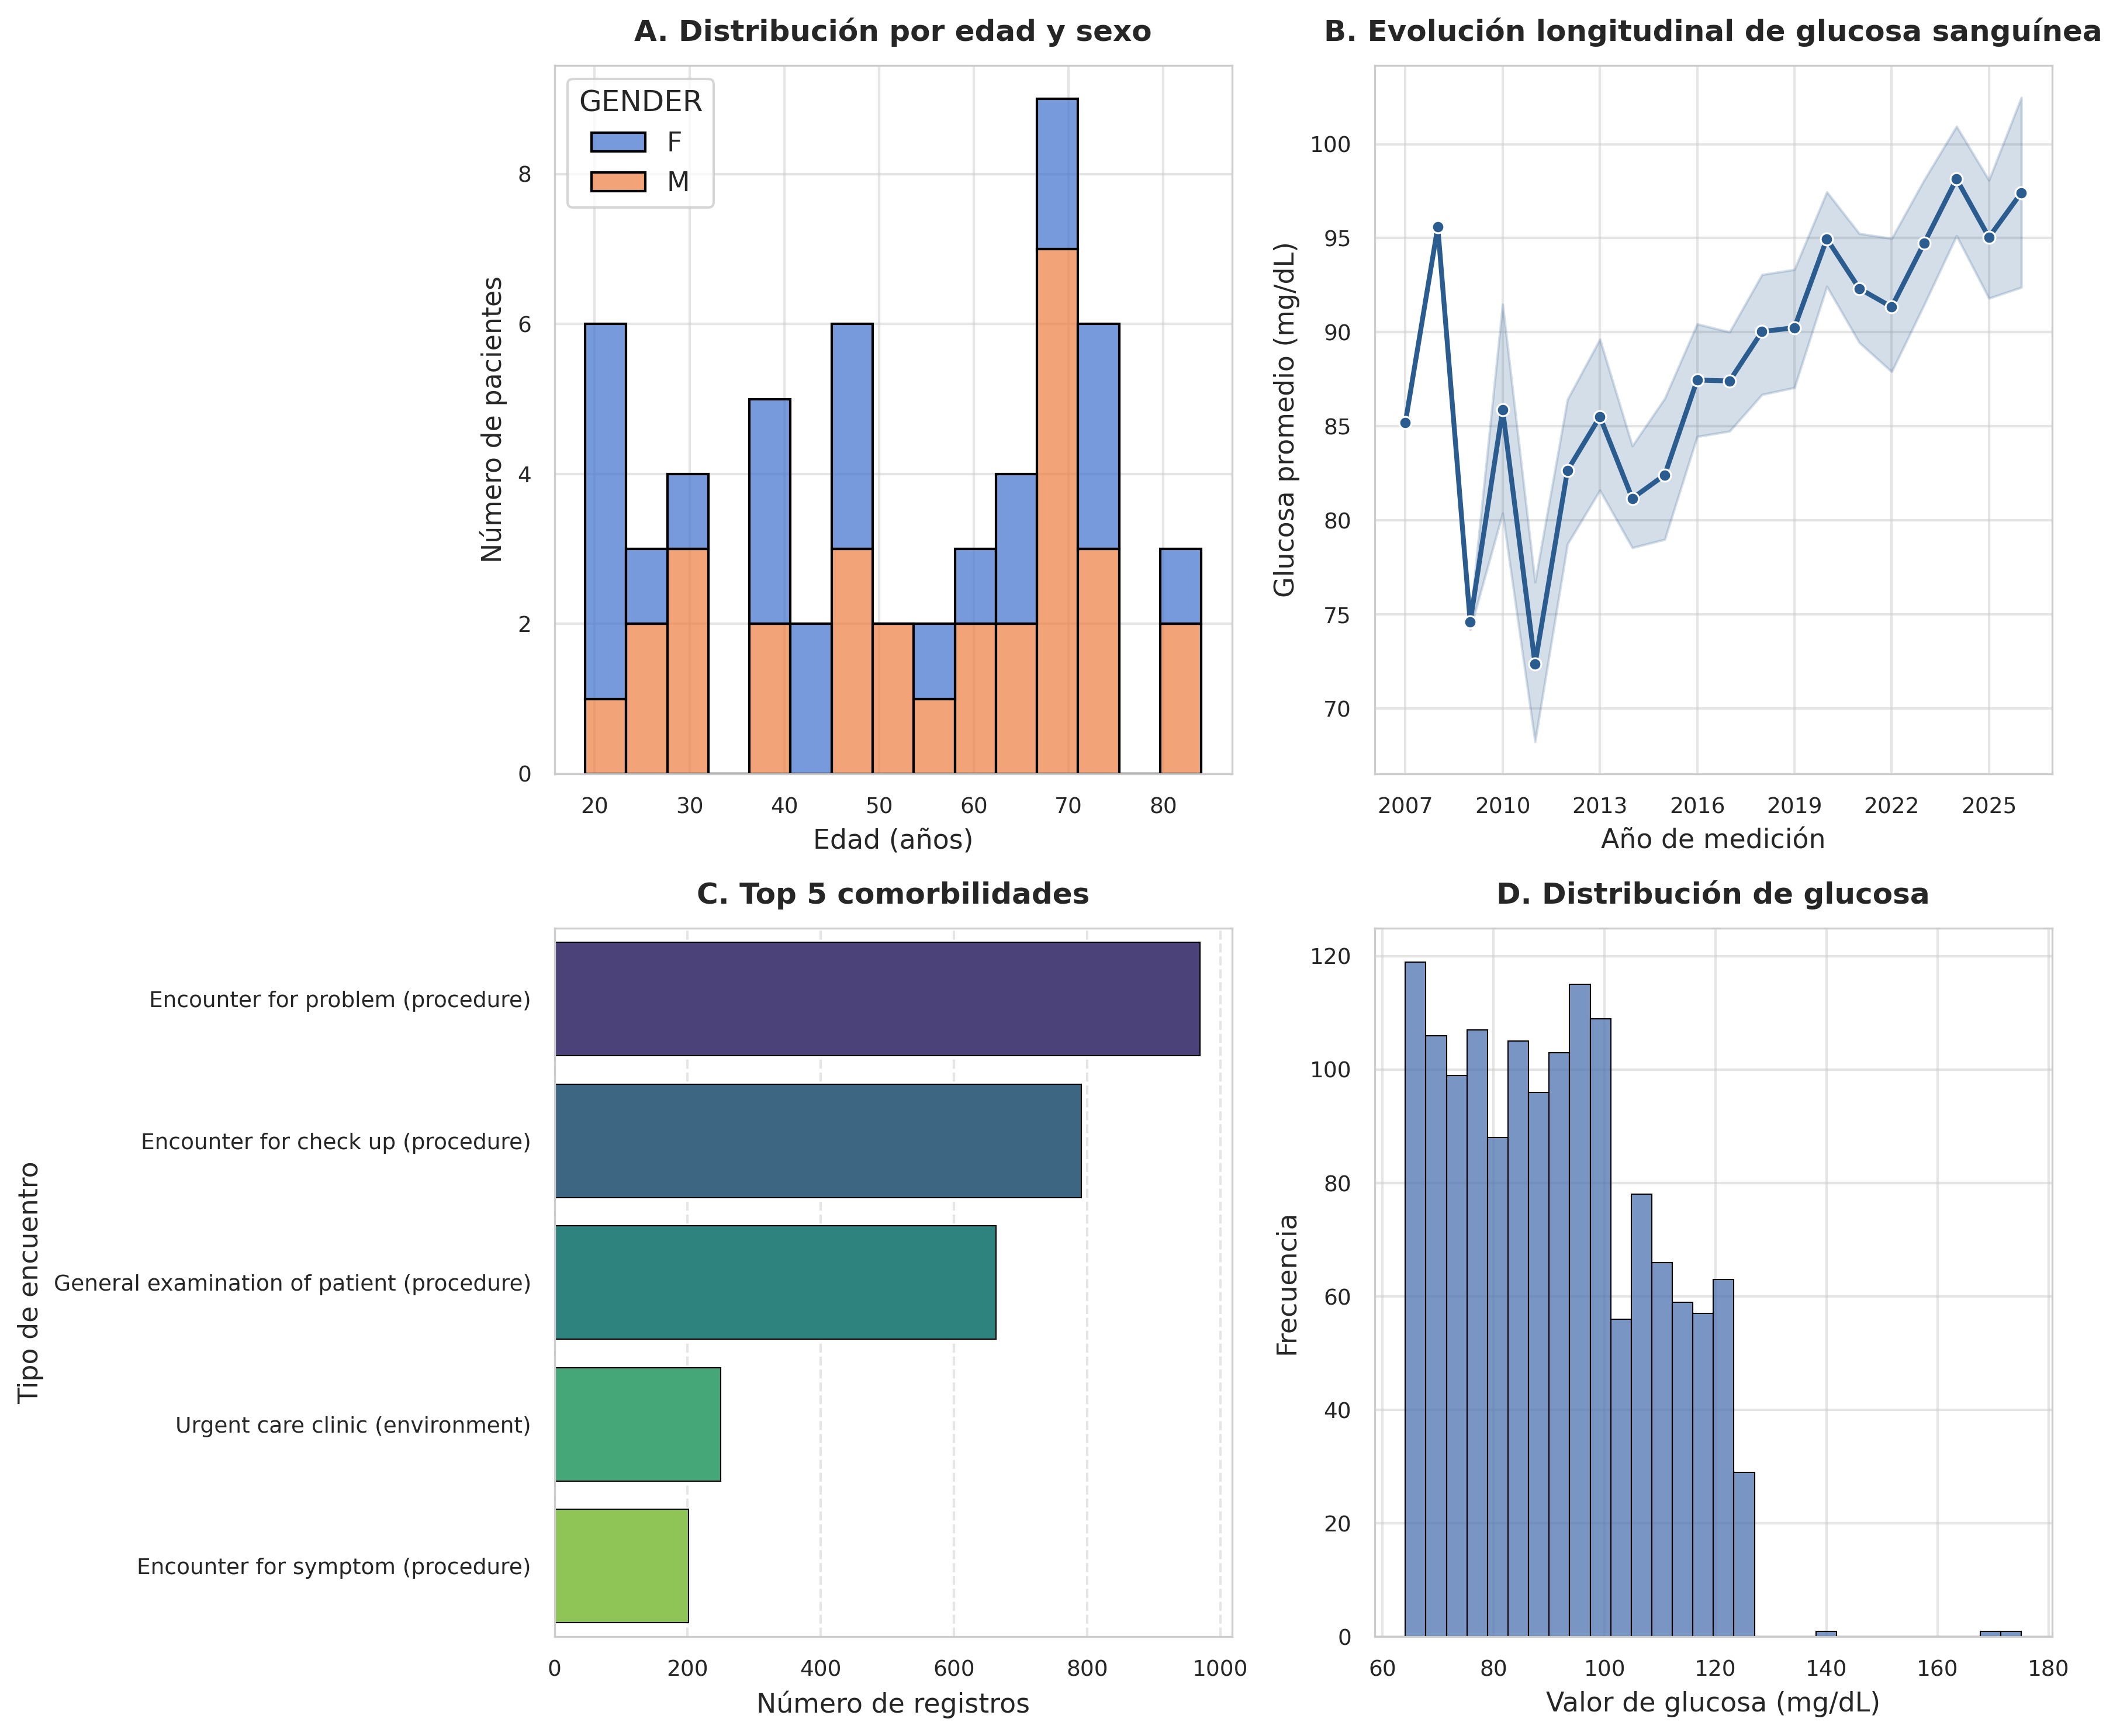

In [14]:
#5. Construir una figura multipanel (2×2) con tamaño y tipografía de publicación.

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14,
    'axes.linewidth': 0.8,
    'grid.alpha': 0.5
})

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
palette_pub = sns.color_palette("muted")

#Panel A
if 'cohorte_patients' in locals() and 'EDAD' in cohorte_patients.columns:
    sns.histplot(
        data=cohorte_patients, x='EDAD', hue='GENDER',
        multiple='stack', bins=15, palette=palette_pub[:2],
        ax=axes[0, 0], edgecolor='black', linewidth=1
    )
axes[0, 0].set_title('A. Distribución por edad y sexo', fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Edad (años)')
axes[0, 0].set_ylabel('Número de pacientes')
axes[0, 0].grid(True)


#Panel B
if 'df_analito' in locals():
    df_analito_diab = df_analito[df_analito['VALUE_NUM'] > 30].copy()
    if 'AÑO' not in df_analito_diab.columns and 'DATE' in df_analito_diab.columns:
        df_analito_diab['AÑO'] = pd.to_datetime(df_analito_diab['DATE']).dt.year.dropna().astype(int)

    sns.lineplot(
        data=df_analito_diab, x='AÑO', y='VALUE_NUM',
        marker='o', color='#2b5c8f', ax=axes[0, 1], linewidth=2, markersize=5
    )
axes[0, 1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0, 1].set_title('B. Evolución longitudinal de glucosa sanguínea', fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Año de medición')
axes[0, 1].set_ylabel('Glucosa promedio (mg/dL)')
axes[0, 1].grid(True)

#Panel C
if 'cohorte_encounters' in locals():
    top_condiciones = cohorte_encounters['DESCRIPTION'].dropna().value_counts().head(5)
    sns.barplot(
        x=top_condiciones.values, y=top_condiciones.index,
        hue=top_condiciones.index, palette='viridis', legend=False,
        ax=axes[1, 0], edgecolor='black', linewidth=0.5
    )
axes[1, 0].set_title('C. Top 5 comorbilidades', fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Número de registros')
axes[1, 0].set_ylabel('Tipo de encuentro')
axes[1, 0].grid(axis='x', linestyle='--')


#Panel D
if 'df_analito' in locals():
    sns.histplot(
        df_analito_diab['VALUE_NUM'], bins=30,
        color='#4c72b0', ax=axes[1, 1], edgecolor='black', linewidth=0.5
    )
axes[1, 1].set_title('D. Distribución de glucosa', fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Valor de glucosa (mg/dL)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

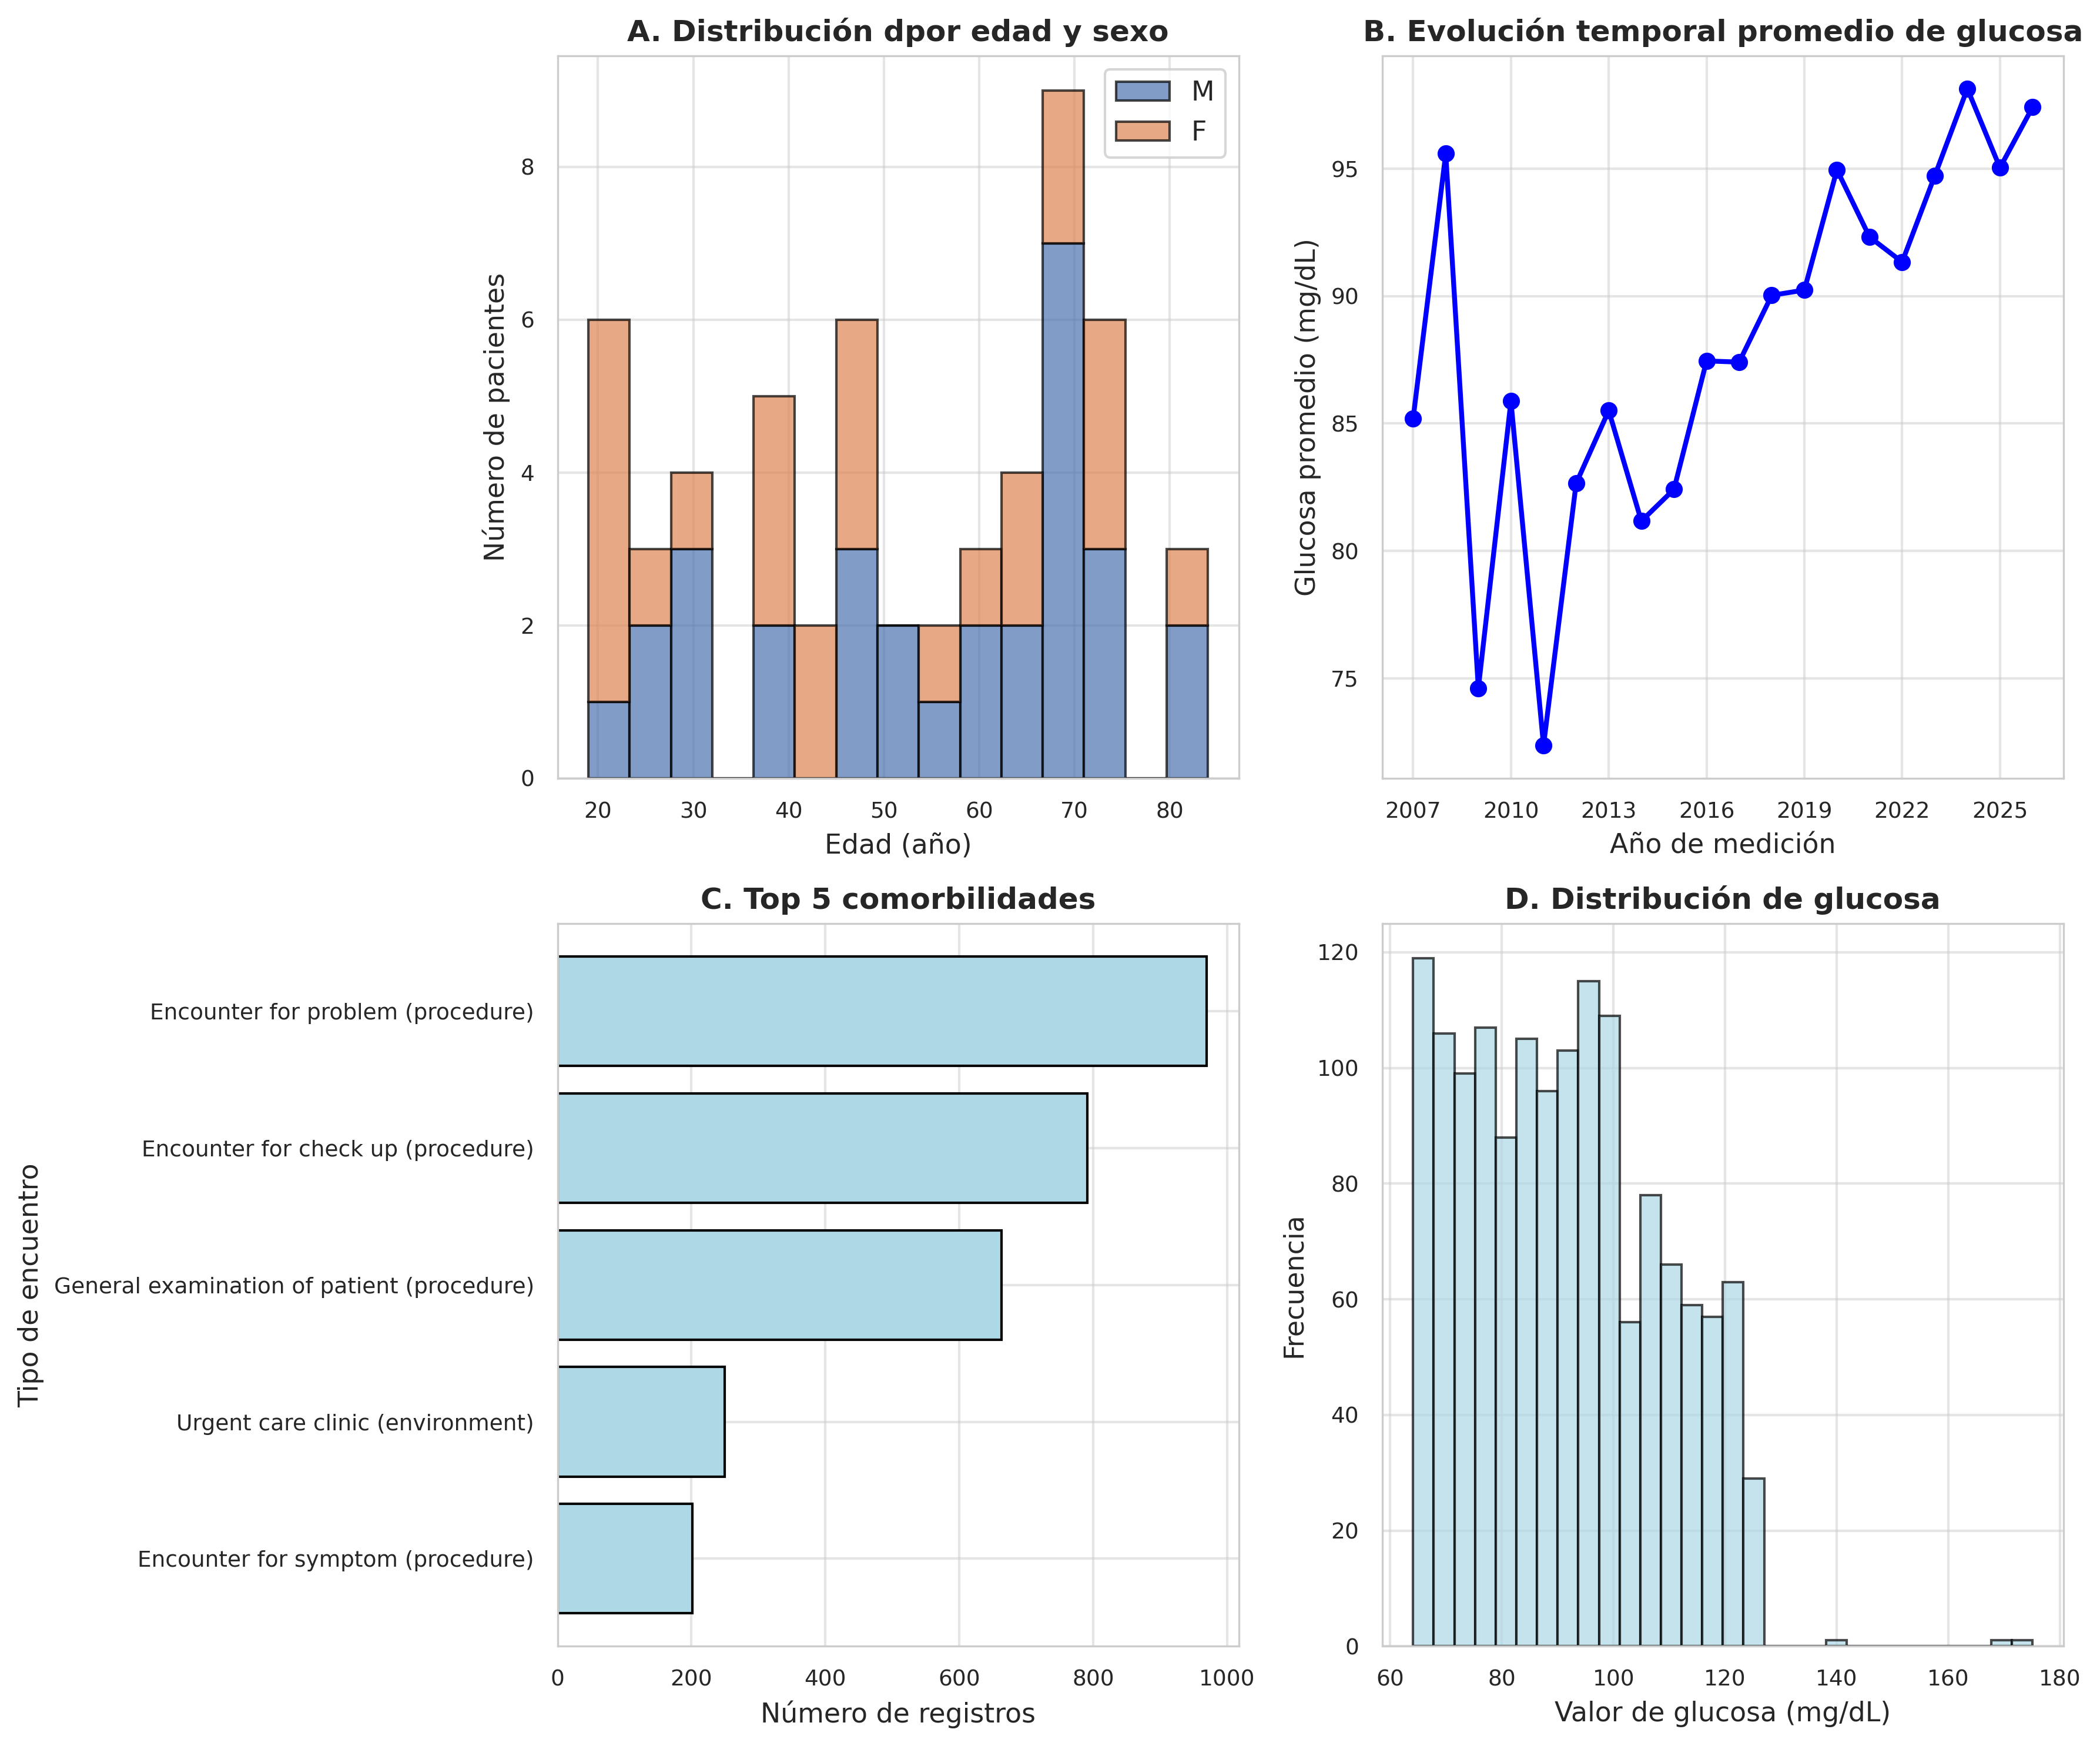

In [36]:
#6.1 Reproducir la misma figura clave en matplotlib puro

#Datos filtrados
df_sangre = df_analito[df_analito['VALUE_NUM'] > 30].copy()
df_sangre['AÑO'] = pd.to_datetime(df_sangre['DATE']).dt.year.dropna().astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)

#Panel A
edades_h = cohorte_patients[cohorte_patients['GENDER'] == 'M']['EDAD']
edades_m = cohorte_patients[cohorte_patients['GENDER'] == 'F']['EDAD']
axes[0, 0].hist([edades_h, edades_m], bins=15, stacked=True, label=['M', 'F'], edgecolor='black', alpha=0.7)
axes[0, 0].set_title('A. Distribución dpor edad y sexo', fontweight='bold')
axes[0, 0].set_xlabel('Edad (año)')
axes[0, 0].set_ylabel('Número de pacientes')
axes[0, 0].legend()

#Panel B
promedios_año = df_sangre.groupby('AÑO')['VALUE_NUM'].mean()
axes[0, 1].plot(promedios_año.index, promedios_año.values, marker='o', color='blue', linewidth=2)
axes[0, 1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0, 1].set_title('B. Evolución temporal promedio de glucosa', fontweight='bold')
axes[0, 1].set_xlabel('Año de medición')
axes[0, 1].set_ylabel('Glucosa promedio (mg/dL)')

#Panel C
top_enc = cohorte_encounters['DESCRIPTION'].dropna().value_counts().head(5)
axes[1, 0].barh(top_enc.index[::-1], top_enc.values[::-1], color='lightblue', edgecolor='black')
axes[1, 0].set_title('C. Top 5 comorbilidades', fontweight='bold')
axes[1, 0].set_xlabel('Número de registros')
axes[1, 0].set_ylabel('Tipo de encuentro')


#Panel D
vals = df_sangre['VALUE_NUM'].dropna()
axes[1, 1].hist(vals, bins=30, color='lightblue', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('D. Distribución de glucosa', fontweight='bold')
axes[1, 1].set_xlabel('Valor de glucosa (mg/dL)')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

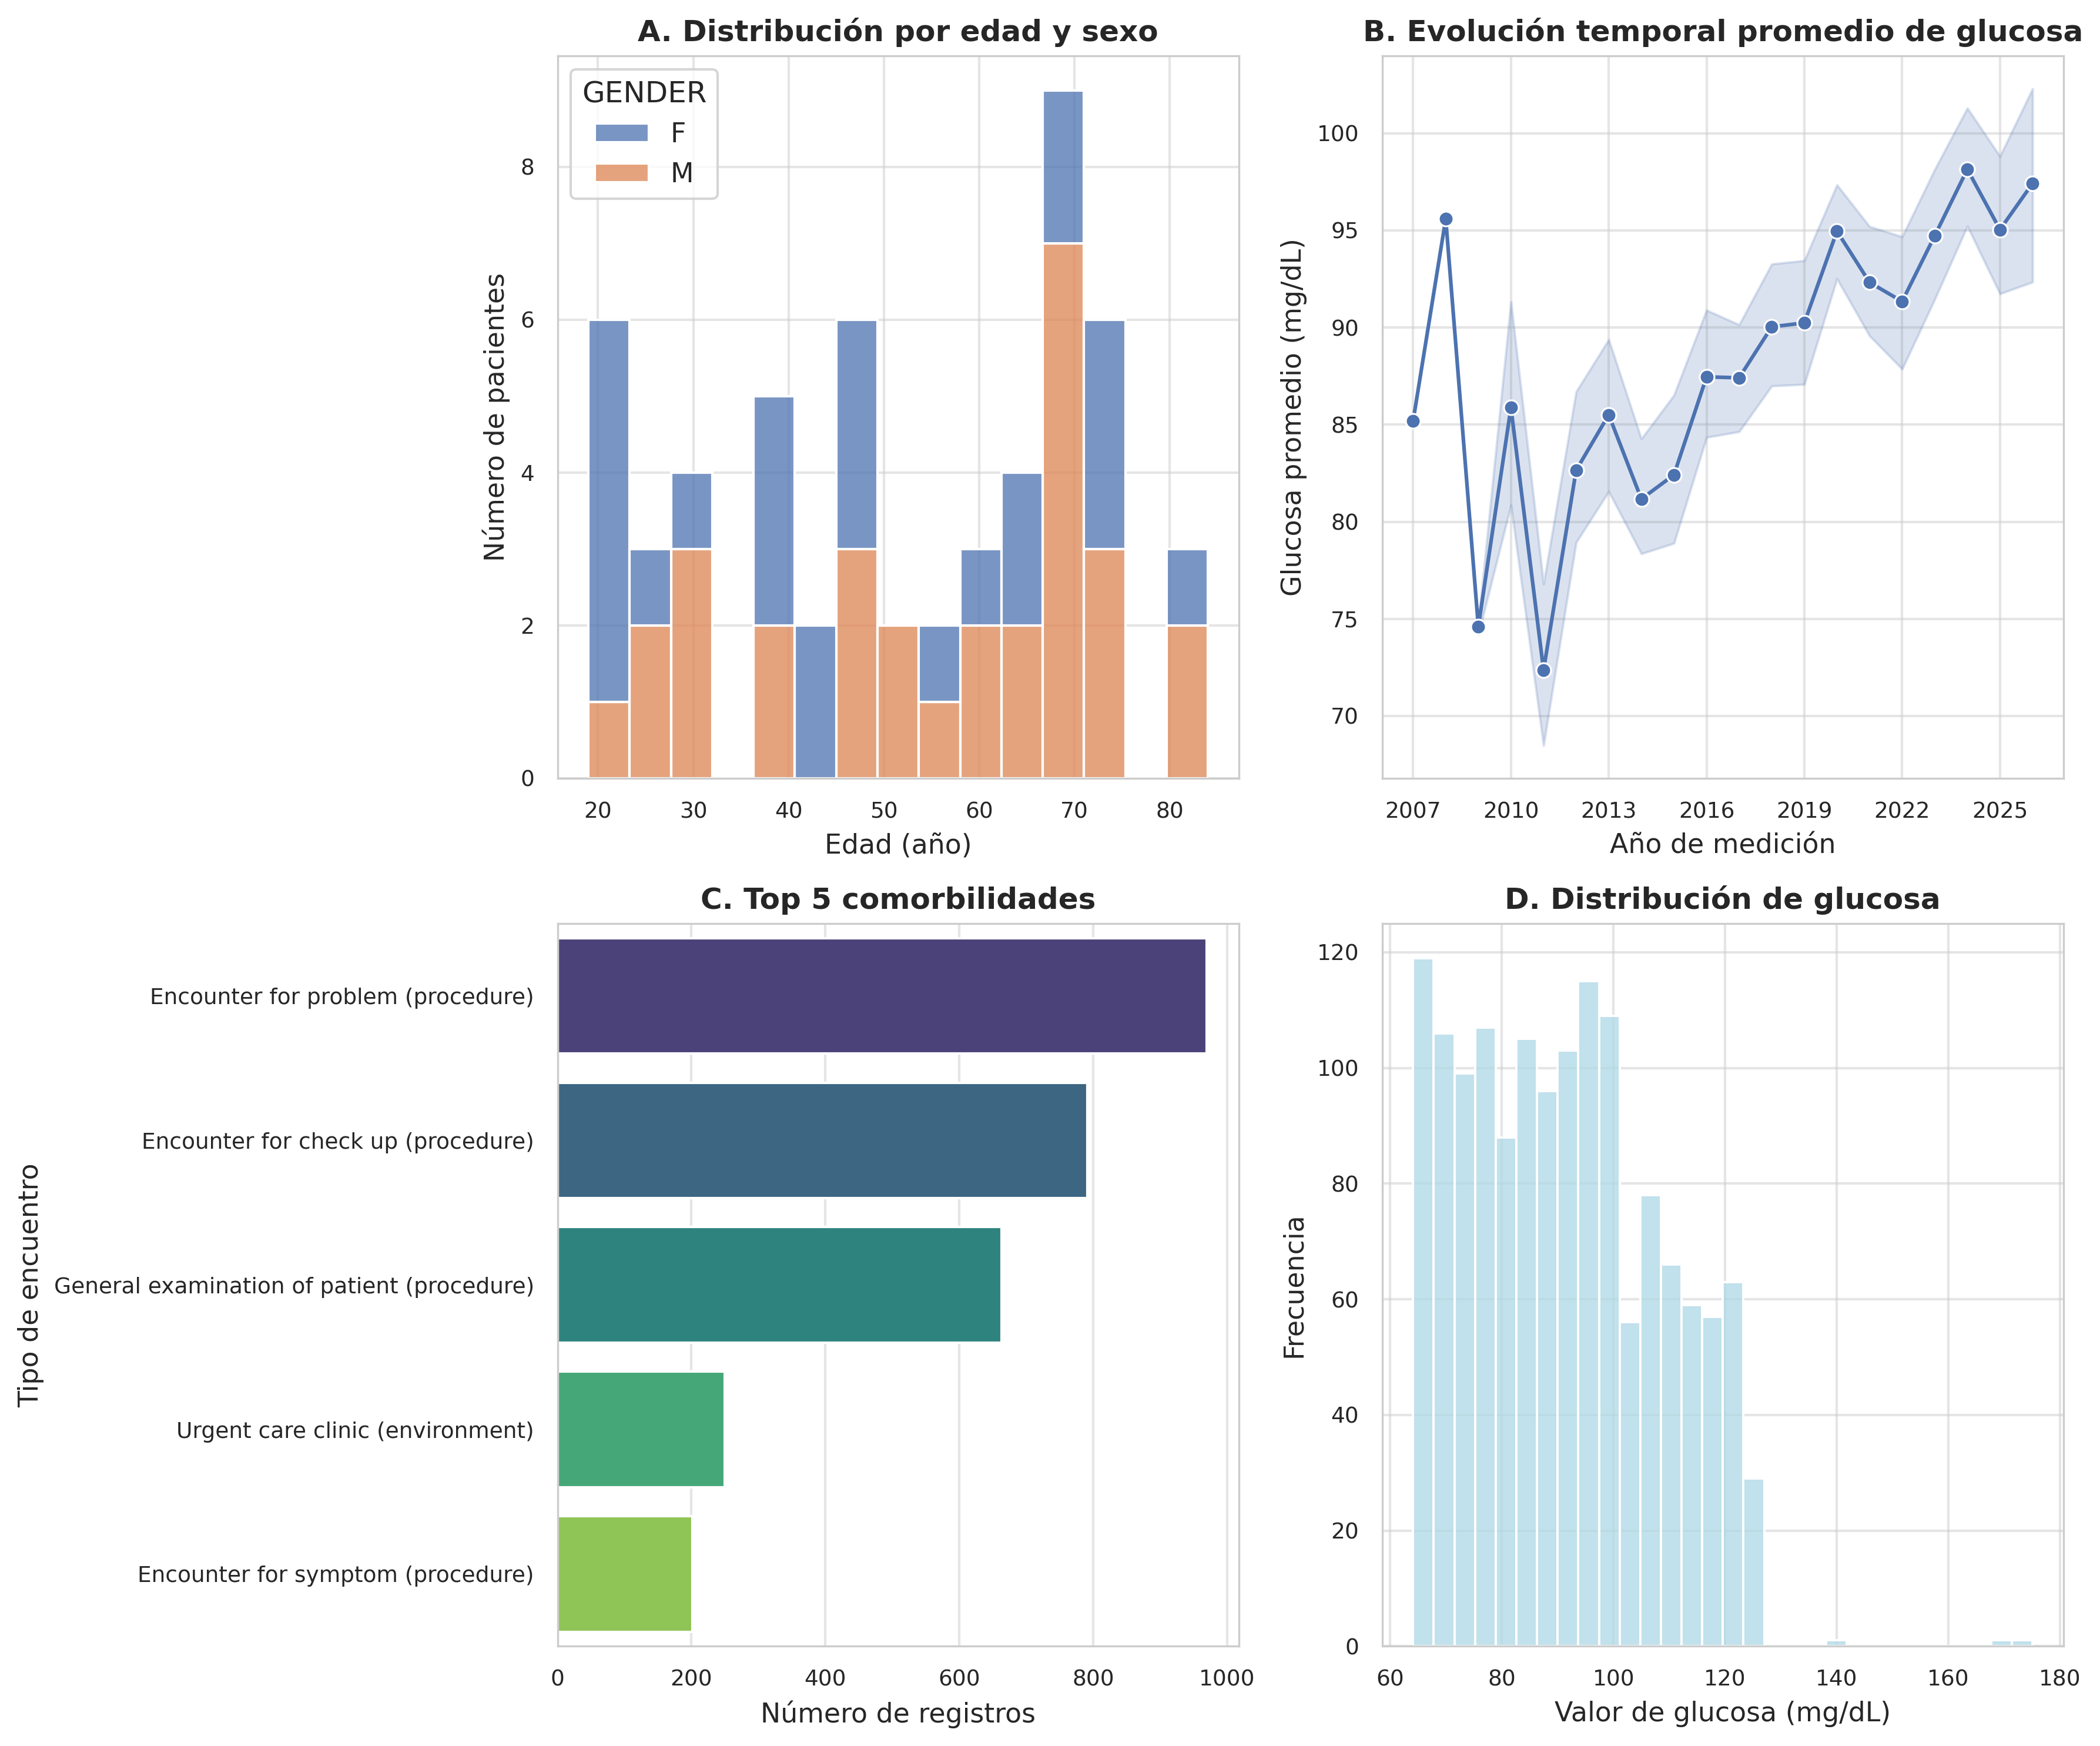

In [34]:
#6.2 Reproducir la misma figura clave en seaborn
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)

#Panel A
sns.histplot(data=cohorte_patients, x='EDAD', hue='GENDER', multiple='stack', bins=15, ax=axes[0, 0])
axes[0, 0].set_title('A. Distribución por edad y sexo', fontweight='bold')
axes[0, 0].set_xlabel('Edad (año)')
axes[0, 0].set_ylabel('Número de pacientes')

#Panel B
sns.lineplot(data=df_sangre, x='AÑO', y='VALUE_NUM', marker='o', ax=axes[0, 1])
axes[0, 1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0, 1].set_title('B. Evolución temporal promedio de glucosa', fontweight='bold')
axes[0, 1].set_xlabel('Año de medición')
axes[0, 1].set_ylabel('Glucosa promedio (mg/dL)')

#Panel C
top_enc = cohorte_encounters['DESCRIPTION'].dropna().value_counts().head(5)
sns.barplot(x=top_enc.values, y=top_enc.index, hue=top_enc.index, palette='viridis', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('C. Top 5 comorbilidades', fontweight='bold')
axes[1, 0].set_xlabel('Número de registros')
axes[1, 0].set_ylabel('Tipo de encuentro')

#Panel D
sns.histplot(df_sangre['VALUE_NUM'], bins=30, color='lightblue', ax=axes[1, 1])
axes[1, 1].set_title('D. Distribución de glucosa', fontweight='bold')
axes[1, 1].set_xlabel('Valor de glucosa (mg/dL)')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [26]:
#6.3 Reproducir la misma figura clave en plotly; comparar esfuerzo, control y resultado

from plotly.subplots import make_subplots
import plotly.graph_objects as px_go
import plotly.express as px

fig = make_subplots(rows=2, cols=2, subplot_titles=(
        'A. Distribución por edad',
        'B. Evolución temporal promedio de glucosa',
        'C. Top 5 comorbilidades',
        'D. Distribución de glucosa'
    )
)

#Panel A
fig.add_trace(px_go.Histogram(x=cohorte_patients['EDAD'], name='Edad'), row=1, col=1)

#Panel B
prom = df_sangre.groupby('AÑO')['VALUE_NUM'].mean().reset_index()
fig.add_trace(px_go.Scatter(x=prom['AÑO'], y=prom['VALUE_NUM'], mode='lines+markers', name='Glucosa prom'), row=1, col=2)

#Panel C
top_enc = cohorte_encounters['DESCRIPTION'].dropna().value_counts().head(5)
fig.add_trace(px_go.Bar(x=top_enc.values, y=top_enc.index, orientation='h', name='Encuentros'), row=2, col=1)

#Panel D
fig.add_trace(px_go.Histogram(x=df_sangre['VALUE_NUM'], nbinsx=30, name='Glucosa (mg/dL)'), row=2, col=2)

#Ejes
fig.update_xaxes(title_text="Edad (años)", row=1, col=1)
fig.update_yaxes(title_text="Número de pacientes", row=1, col=1)

fig.update_xaxes(title_text="Año de medición", row=1, col=2)
fig.update_yaxes(title_text="Glucosa promedio (mg/dL)", row=1, col=2)

fig.update_xaxes(title_text="Número de registros", row=2, col=1)
fig.update_yaxes(title_text="Tipo de encuentro", row=2, col=1)

fig.update_xaxes(title_text="Valor de glucosa (mg/dL)", row=2, col=2)
fig.update_yaxes(title_text="Frecuencia", row=2, col=2)

fig.update_layout(height=800, width=1000, title_text="<b>Figura multipanel (plotly)</b>", template="plotly_white")
fig.show()

In [11]:
#Comparar esfuerzo, control y resultado
#El esfuerzo es muy alto en matplotlib, ya que hay que calcular las agregaciones a mano y cada subcuadro individualmente. También es alto en plotly por la agregación de trazoz individuales, y es bajo en seaborn al tener agregaciones automáticas en una sola linea.
#El nivel de control es total en matplotlib, desde el espaciado, las fuentes, ejes y el grosor de los bordes. En seaborn es alto y permite tener un código más limpio. Y es medio en plotly, porque se me complico controlar cada elemento de la gráfica en cada uno de las celdas.
#En cuanto al resultado, en matplotlib y seaborn considero que es bueno e ideal para exportar los gráficos y usarlos en publicaciones, mientras que en plotly es interactivo e ideal para publicaciones en páginas web, pero no logré que se apreciara de manera adecuada cada barra en los diferentes gráficos.

In [12]:
#7. Construir la tabla de características basales (Tabla 1) de tu cohorte

#Obtener primera glucosa basal limpia por paciente (> 30 mg/dL)
df_sangre_basal = (
    df_analito[df_analito['VALUE_NUM'] > 30]
    .sort_values('DATE')
    .groupby('PATIENT')['VALUE_NUM']
    .first()
)

#Unir glucosa basal a la cohorte de pacientes
tabla1_df = cohorte_patients.copy()
if 'PATIENT' not in tabla1_df.columns:
    col_id_p = [c for c in tabla1_df.columns if c.upper() in ['ID', 'PATIENT_ID', 'SUBJECT_ID']][0]
    tabla1_df['PATIENT'] = tabla1_df[col_id_p].astype(str)

tabla1_df = tabla1_df.set_index('PATIENT')
tabla1_df['GLUCOSA_BASAL'] = df_sangre_basal

#3. Métricas para Tabla 1
total_pacientes = len(tabla1_df)

#Edad
m_edad, std_edad = tabla1_df['EDAD'].mean(), tabla1_df['EDAD'].std()
med_edad = tabla1_df['EDAD'].median()
q25_edad, q75_edad = tabla1_df['EDAD'].quantile(0.25), tabla1_df['EDAD'].quantile(0.75)

#Sexo
n_fem = (tabla1_df['GENDER'] == 'F').sum()
pct_fem = (n_fem / total_pacientes) * 100
n_mas = (tabla1_df['GENDER'] == 'M').sum()
pct_mas = (n_mas / total_pacientes) * 100

#Glucosa basal
glu_clean = tabla1_df['GLUCOSA_BASAL'].dropna()
m_glu, std_glu = glu_clean.mean(), glu_clean.std()
med_glu = glu_clean.median()
q25_glu, q75_glu = glu_clean.quantile(0.25), glu_clean.quantile(0.75)

#Tabla 1
tabla1_data = [
    {'Característica': 'Total de pacientes, n', 'Valor': f"{total_pacientes}"},
    {'Característica': 'Edad (años), media ± DE', 'Valor': f"{m_edad:.1f} ± {std_edad:.1f}"},
    {'Característica': 'Edad (años), mediana (IQR)', 'Valor': f"{med_edad:.1f} ({q25_edad:.1f} - {q75_edad:.1f})"},
    {'Característica': 'Sexo: femenino, n (%)', 'Valor': f"{n_fem} ({pct_fem:.1f}%)"},
    {'Característica': 'Sexo: masculino, n (%)', 'Valor': f"{n_mas} ({pct_mas:.1f}%)"},
    {'Característica': 'Glucosa basal (mg/dL), Media ± DE', 'Valor': f"{m_glu:.1f} ± {std_glu:.1f}"},
    {'Característica': 'Glucosa basal (mg/dL), Mediana (IQR)', 'Valor': f"{med_glu:.1f} ({q25_glu:.1f} - {q75_glu:.1f})"}
]

df_tabla1 = pd.DataFrame(tabla1_data)
display(df_tabla1.style.hide(axis='index'))

Característica,Valor / Resumen
"Total de pacientes, N",55
"Edad (años), Media ± DE",51.5 ± 19.4
"Edad (años), Mediana (IQR)",50.0 (37.5 - 67.0)
"Sexo: Femenino, n (%)",25 (45.5%)
"Sexo: Masculino, n (%)",30 (54.5%)
"Glucosa basal (mg/dL), Media ± DE",85.5 ± 18.0
"Glucosa basal (mg/dL), Mediana (IQR)",82.8 (76.0 - 93.9)


In [37]:
#8. Exportar la figura final en PDF vectorial y en PNG a 300 dpi
fig.savefig('figura_cohorte_png.png', dpi=300, bbox_inches='tight')
fig.savefig('figura_cohorte_pdf.pdf', format='pdf', bbox_inches='tight')

print("Archivos exportados")

Archivos exportados
